# Stage 4a — W2V2-L2 Linear Head
### Alertreck · Transfer Learning Paradigm

Trains a lightweight MLP classification head over **frozen wav2vec 2.0 layer-2 embeddings**
pre-extracted in Stage 2b. The 94M-parameter backbone is never touched during training;
only the head (~527K parameters) is updated.

---

## Architecture

```
Input  (768-dim L2-normalised W2V2 embedding)
  ├── Linear(768 → 512) → BN → ReLU → Dropout(0.3)
  ├── Linear(512 → 256) → BN → ReLU → Dropout(0.3)
  └── Linear(256 → 7)   →  logits
```

## Training strategy

| Phase | Epochs | Train data | LR schedule |
|-------|--------|------------|-------------|
| A | 20 | clean + aug_A (light noise, ×1) | cosine decay 3e-4 → ~0 |
| B | 15 | clean + aug_B (medium noise, ×2) | restart 3e-4 → ~0 |
| C | until patience | clean + aug_C (heavy noise, ×3) | restart 3e-4 → ~0 |

All embeddings are loaded into RAM at the start — no I/O bottleneck during training.

## Datasets required
- `alertreck-w2v2-embeddings` — output of `02b-prepare-w2v2-embeddings.ipynb`

## Cell 1 — Imports

In [1]:
import json, math, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    roc_auc_score, roc_curve,
)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : Tesla T4


## Cell 2 — Configuration

In [2]:
CFG = {
    # ── paths ── update data_root to match your Kaggle dataset mount path
    'data_root':    Path('/kaggle/input/datasets/nobuhlemanga/dataw2v2-embeddings/w2v2_l2'),
    'output_dir':   Path('/kaggle/working/w2v2_l2'),

    # ── model ──
    'embed_dim':    768,
    'n_classes':    7,
    'hidden_dims':  [512, 256],
    'dropout':      0.5,

    # ── training ──
    # Frozen embeddings + tiny head plateau fast, so the run is short and the LR
    # is a SINGLE continuous cosine over `epochs` (no per-phase restart) — this
    # keeps the curriculum but removes the sawtooth at phase boundaries.
    'lr':           3e-4,
    'weight_decay': 5e-4,
    'batch_size':   512,
    'epochs':       45,
    'patience':     8,
    'label_smooth': 0.1,
    'phase_epochs': {'A': 12, 'B': 8, 'C': 999},

    # ── labels ──
    'class_names': [
        'bg_animals', 'bg_wind_rain',
        'chainsaw', 'dog', 'gunshot', 'human', 'vehicle'
    ],
    'label_map': {
        'background_animals':   0,
        'background_wind_rain': 1,
        'threat_chainsaw':      2,
        'threat_dog':           3,
        'threat_gunshot':       4,
        'threat_human':         5,
        'threat_vehicle':       6,
    }
}

output_dir = CFG['output_dir']
output_dir.mkdir(parents=True, exist_ok=True)
data_root = CFG['data_root']

print(f'Data root : {data_root}')
print(f'Output    : {output_dir}')
print()

# Verify all embedding directories are present
splits = ['train', 'val', 'test', 'train_aug_A', 'train_aug_B', 'train_aug_C']
for split in splits:
    d = data_root / split
    n = len(list(d.glob('*.npz'))) if d.exists() else 0
    status = 'OK' if n > 0 else 'MISSING'
    print(f'  {split:<16} {n:>3} shards  [{status}]')

Data root : /kaggle/input/datasets/nobuhlemanga/dataw2v2-embeddings/w2v2_l2
Output    : /kaggle/working/w2v2_l2

  train             16 shards  [OK]
  val                7 shards  [OK]
  test               7 shards  [OK]
  train_aug_A       16 shards  [OK]
  train_aug_B       32 shards  [OK]
  train_aug_C       48 shards  [OK]


## Cell 3 — Dataset and DataLoaders

In [3]:
class EmbeddingDataset(Dataset):
    """Loads all .npz shards from a directory into memory as tensors."""

    def __init__(self, shard_dir: Path):
        shards = sorted(Path(shard_dir).glob('*.npz'))
        if not shards:
            raise FileNotFoundError(f'No .npz shards in {shard_dir}')
        Xs, ys = [], []
        for s in shards:
            d = np.load(s)
            Xs.append(d['X'])
            ys.append(d['y'])
        self.X = torch.from_numpy(np.concatenate(Xs, axis=0)).float()
        self.y = torch.from_numpy(np.concatenate(ys, axis=0)).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def make_loader(shard_dirs, batch_size, shuffle):
    if isinstance(shard_dirs, Path):
        shard_dirs = [shard_dirs]
    datasets = [EmbeddingDataset(d) for d in shard_dirs]
    ds = datasets[0] if len(datasets) == 1 else ConcatDataset(datasets)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=(device.type == 'cuda'))


print('Loading val  embeddings into RAM…')
val_loader  = make_loader(data_root / 'val',  CFG['batch_size'], shuffle=False)
print(f'  val  : {len(val_loader.dataset):,} embeddings')

print('Loading test embeddings into RAM…')
test_loader = make_loader(data_root / 'test', CFG['batch_size'], shuffle=False)
print(f'  test : {len(test_loader.dataset):,} embeddings')

Loading val  embeddings into RAM…
  val  : 6,779 embeddings
Loading test embeddings into RAM…
  test : 6,764 embeddings


In [4]:
# Diagnostic — check class distribution in each split
from collections import Counter

for split_name, loader in [('val', val_loader), ('test', test_loader)]:
    y_all = loader.dataset.dataset.y if hasattr(loader.dataset, 'dataset') else loader.dataset.y
    counts = Counter(y_all.numpy())
    total  = len(y_all)
    print(f'{split_name} — {total} embeddings')
    for cls_id in sorted(counts):
        name = CFG['class_names'][cls_id]
        n    = counts[cls_id]
        print(f'  {name:<22}  {n:>4}  ({100*n/total:5.1f}%)')
    print()

# Also check train clean split
train_clean = EmbeddingDataset(data_root / 'train')
counts_tr   = Counter(train_clean.y.numpy())
total_tr    = len(train_clean.y)
print(f'train (clean) — {total_tr} embeddings')
for cls_id in sorted(counts_tr):
    name = CFG['class_names'][cls_id]
    n    = counts_tr[cls_id]
    print(f'  {name:<22}  {n:>4}  ({100*n/total_tr:5.1f}%)')

val — 6779 embeddings
  bg_animals              1339  ( 19.8%)
  bg_wind_rain            1882  ( 27.8%)
  chainsaw                 564  (  8.3%)
  dog                      224  (  3.3%)
  gunshot                 1850  ( 27.3%)
  human                    697  ( 10.3%)
  vehicle                  223  (  3.3%)

test — 6764 embeddings
  bg_animals              1373  ( 20.3%)
  bg_wind_rain            1855  ( 27.4%)
  chainsaw                 562  (  8.3%)
  dog                      219  (  3.2%)
  gunshot                 1840  ( 27.2%)
  human                    696  ( 10.3%)
  vehicle                  219  (  3.2%)

train (clean) — 15710 embeddings
  bg_animals              3053  ( 19.4%)
  bg_wind_rain            4195  ( 26.7%)
  chainsaw                1594  ( 10.1%)
  dog                      637  (  4.1%)
  gunshot                 3162  ( 20.1%)
  human                   2431  ( 15.5%)
  vehicle                  638  (  4.1%)


## Cell 4 — Model

In [5]:
class W2V2Head(nn.Module):
    """Lightweight MLP classification head over frozen W2V2 embeddings."""

    def __init__(self, embed_dim=768, hidden_dims=None, n_classes=7, dropout=0.3):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [512, 256]
        layers = []
        in_dim = embed_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = W2V2Head(
    embed_dim=CFG['embed_dim'],
    hidden_dims=CFG['hidden_dims'],
    n_classes=CFG['n_classes'],
    dropout=CFG['dropout'],
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'W2V2Head parameters : {n_params:,}')
print(model)

W2V2Head parameters : 528,391
W2V2Head(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=256, out_features=7, bias=True)
  )
)


## Cell 4b — Three hyperparameter experiments (replaces Optuna)

We confirmed on the CNN that a short-proxy Optuna search can pick a worse-generalising config. So here too we run **three explicit experiments**, each trained through the **full curriculum**, and keep the model with the highest **val macro-F1**:

| | lr | batch | weight_decay | dropout | label_smooth | hidden_dims |
|---|---|---|---|---|---|---|
| **A** baseline | 3e-4 | 512 | 1e-4 | 0.3 | 0.10 | [512, 256] |
| **B** higher-LR | 1e-3 | 512 | 1e-4 | 0.3 | 0.05 | [512, 256] |
| **C** smaller+reg | 3e-4 | 512 | 3e-4 | 0.4 | 0.10 | [256, 128] |

The head trains on frozen embeddings, so each full run is **seconds** — all three finish in well under a minute. The winner's checkpoint becomes `best_model.pt`, the comparison is saved to `experiments.json`, and the downstream eval/ONNX cells run on it unchanged.

In [6]:
# ── 4b. Three hyperparameter experiments ──────────────────────────────────────
# Each config is trained through the FULL curriculum (next cell) and the best by
# VALIDATION macro-F1 is kept (experiments.json). Training is seconds on frozen
# embeddings, so all three are cheap. Selection is on val only.
# Regularisation is deliberately strong (dropout 0.5, wd 5e-4) — a 528K-param head
# on frozen embeddings overfits easily, so this keeps train/val close.
EXPERIMENTS = [
    {'name': 'A_baseline',  'lr': 3e-4, 'batch_size': 512, 'weight_decay': 5e-4,
     'dropout': 0.5, 'label_smooth': 0.10, 'hidden_dims': [512, 256]},
    {'name': 'B_higherLR',  'lr': 1e-3, 'batch_size': 512, 'weight_decay': 5e-4,
     'dropout': 0.5, 'label_smooth': 0.05, 'hidden_dims': [512, 256]},
    {'name': 'C_smaller',   'lr': 3e-4, 'batch_size': 512, 'weight_decay': 1e-3,
     'dropout': 0.5, 'label_smooth': 0.10, 'hidden_dims': [256, 128]},
]

print(f'{len(EXPERIMENTS)} experiments (each trains in seconds on frozen embeddings):')
for e in EXPERIMENTS:
    print(f"  {e['name']:<12} " + "  ".join(f'{k}={v}' for k, v in e.items() if k != 'name'))

3 experiments (each trains in seconds on frozen embeddings):
  A_baseline   lr=0.0003  batch_size=512  weight_decay=0.0005  dropout=0.5  label_smooth=0.1  hidden_dims=[512, 256]
  B_higherLR   lr=0.001  batch_size=512  weight_decay=0.0005  dropout=0.5  label_smooth=0.05  hidden_dims=[512, 256]
  C_smaller    lr=0.0003  batch_size=512  weight_decay=0.001  dropout=0.5  label_smooth=0.1  hidden_dims=[256, 128]


## Cell 5 — Training loop

In [7]:
# ── 5. Train the 3 experiments (full curriculum) & keep the best ──────────────
import shutil, gc


def _load_tr(phase, bs):
    return make_loader([data_root / 'train', data_root / f'train_aug_{phase}'], bs, True)


def run_experiment(exp):
    """Full-curriculum training for one W2V2-head config. Returns
    (best_val_f1, best_epoch, best_phase, history, ckpt_path).

    The A->B->C curriculum (progressively harder augmentation) is kept, but the
    learning rate is a SINGLE continuous cosine over the whole run — it does NOT
    restart at phase boundaries. That removes the LR spikes that made the curves
    look jagged, so only the (small) data-difficulty step at each phase remains.
    """
    m    = W2V2Head(CFG['embed_dim'], exp['hidden_dims'], CFG['n_classes'], exp['dropout']).to(device)
    crit = nn.CrossEntropyLoss(label_smoothing=exp['label_smooth'])
    opt  = optim.Adam(m.parameters(), lr=exp['lr'], weight_decay=exp['weight_decay'])

    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
            'val_f1': [], 'lr': [], 'phase': []}
    order, cap, max_ep = ['A', 'B', 'C'], CFG['phase_epochs'], CFG['epochs']
    pidx, eip, cur = 0, 0, 'A'
    best_f1, best_ep, best_ph, pat = 0.0, 0, 'A', 0
    ckpt_path = output_dir / f"model_{exp['name']}.pt"
    train_loader = _load_tr(cur, exp['batch_size'])

    print(f"\n=== {exp['name']} === lr={exp['lr']:.0e} bs={exp['batch_size']} "
          f"wd={exp['weight_decay']:.0e} drop={exp['dropout']} ls={exp['label_smooth']} "
          f"hidden={exp['hidden_dims']}", flush=True)
    print(f"  {'ph':>2} {'epoch':>5}  {'lr':>9}  "
          f"{'tr_loss':>8} {'tr_acc':>7}  {'va_loss':>8} {'va_acc':>7} {'va_f1':>7}", flush=True)
    t0 = time.time()
    for epoch in range(1, max_ep + 1):
        if eip >= cap[cur] and pidx < len(order) - 1:
            pidx += 1; cur = order[pidx]; eip = 0; pat = 0
            train_loader = _load_tr(cur, exp['batch_size'])

        # single continuous cosine over the whole run (no per-phase restart)
        lr = exp['lr'] * 0.5 * (1.0 + math.cos(math.pi * min((epoch - 1) / max(max_ep - 1, 1), 1.0)))
        for pg in opt.param_groups:
            pg['lr'] = lr

        m.train(); trl = trc = trn = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad(); logits = m(X); loss = crit(logits, y); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0); opt.step()
            trl += loss.item() * len(y); trc += (logits.argmax(1) == y).sum().item(); trn += len(y)

        m.eval(); vl = vc = vn = 0; P, L = [], []
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                logits = m(X); loss = crit(logits, y)
                vl += loss.item() * len(y); vc += (logits.argmax(1) == y).sum().item(); vn += len(y)
                P.append(logits.argmax(1).cpu()); L.append(y.cpu())
        tr_loss, tr_acc = trl / trn, trc / trn
        va_loss, va_acc = vl / vn, vc / vn
        va_f1 = f1_score(torch.cat(L).numpy(), torch.cat(P).numpy(), average='macro', zero_division=0)

        for k, v in [('train_loss', tr_loss), ('val_loss', va_loss), ('train_acc', tr_acc),
                     ('val_acc', va_acc), ('val_f1', va_f1), ('lr', lr), ('phase', cur)]:
            hist[k].append(v)
        eip += 1

        is_best = va_f1 > best_f1
        print(f"  {cur:>2} {epoch:>5}  {lr:>9.2e}  "
              f"{tr_loss:>8.4f} {tr_acc:>7.4f}  {va_loss:>8.4f} {va_acc:>7.4f} {va_f1:>7.4f}"
              f"{'  * best' if is_best else ''}", flush=True)

        if is_best:
            best_f1, best_ep, best_ph, pat = va_f1, epoch, cur, 0
            cfg_safe = {k: str(v) if isinstance(v, Path) else v for k, v in CFG.items()}
            torch.save({'epoch': epoch, 'phase': cur, 'model_state': m.state_dict(),
                        'val_loss': va_loss, 'val_acc': va_acc, 'val_f1': va_f1,
                        'exp': exp, 'cfg': cfg_safe}, ckpt_path)
        else:
            pat += 1
        if pat >= CFG['patience'] and cur == 'C':
            print(f"  early stop at epoch {epoch} (no val-F1 gain for {pat} epochs in phase C)", flush=True)
            break

    print(f"  → {exp['name']} best val macro-F1 = {best_f1:.4f} "
          f"(epoch {best_ep}, phase {best_ph}, {time.time()-t0:.0f}s)", flush=True)
    return best_f1, best_ep, best_ph, hist, ckpt_path


exp_results = []
for exp in EXPERIMENTS:
    bf1, bep, bph, hist, ckpt = run_experiment(exp)
    exp_results.append({'name': exp['name'], 'val_f1': bf1, 'epoch': bep, 'phase': bph,
                        'ckpt': str(ckpt), 'history': hist, 'exp': exp})
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

# ── pick the winner and adopt it ──────────────────────────────────────────────
best = max(exp_results, key=lambda r: r['val_f1'])
shutil.copy(best['ckpt'], output_dir / 'best_model.pt')

print("\n" + "=" * 54)
print("Experiment comparison (val macro-F1):")
for r in sorted(exp_results, key=lambda r: -r['val_f1']):
    mark = '   <-- BEST' if r['name'] == best['name'] else ''
    print(f"  {r['name']:<12} {r['val_f1']:.4f}  (epoch {r['epoch']}, {r['phase']}){mark}")
print(f"\nBest model → {output_dir / 'best_model.pt'}  ({best['name']}, val_F1={best['val_f1']:.4f})")
print("=" * 54)

# adopt the winning config + set the globals the downstream cells expect
CFG.update(best['exp'])
history     = best['history']
best_val_f1 = best['val_f1']
best_epoch  = best['epoch']
best_phase  = best['phase']
model = W2V2Head(CFG['embed_dim'], best['exp']['hidden_dims'],
                 CFG['n_classes'], best['exp']['dropout']).to(device)
model.load_state_dict(torch.load(output_dir / 'best_model.pt', map_location=device)['model_state'])
n_params = sum(p.numel() for p in model.parameters())

# persist every experiment's full per-epoch history (not just the winner)
(output_dir / 'experiments.json').write_text(json.dumps(
    [{'name': r['name'], 'val_f1': r['val_f1'], 'epoch': r['epoch'], 'phase': r['phase'],
      'config': r['exp'], 'history': r['history']} for r in exp_results], indent=2))
print(f"Comparison saved → {output_dir / 'experiments.json'}")


=== A_baseline === lr=3e-04 bs=512 wd=5e-04 drop=0.5 ls=0.1 hidden=[512, 256]
  ph epoch         lr   tr_loss  tr_acc   va_loss  va_acc   va_f1
   A     1   3.00e-04    1.1846  0.6753    1.2780  0.6985  0.5999  * best
   A     2   3.00e-04    0.9321  0.7983    1.0266  0.7299  0.6921  * best
   A     3   2.98e-04    0.8707  0.8256    0.9980  0.7418  0.7048  * best
   A     4   2.97e-04    0.8305  0.8451    0.9813  0.7528  0.7243  * best
   A     5   2.94e-04    0.8003  0.8602    0.9716  0.7590  0.7283  * best
   A     6   2.91e-04    0.7756  0.8692    0.9996  0.7483  0.7215
   A     7   2.86e-04    0.7592  0.8775    0.9858  0.7541  0.7202
   A     8   2.82e-04    0.7429  0.8865    0.9856  0.7596  0.7201
   A     9   2.76e-04    0.7262  0.8909    0.9934  0.7584  0.7178
   A    10   2.70e-04    0.7138  0.8995    0.9747  0.7675  0.7269
   A    11   2.63e-04    0.7014  0.9055    0.9901  0.7612  0.7243
   A    12   2.56e-04    0.6920  0.9090    0.9798  0.7659  0.7329  * best
   B    13   2.

## Cell 6 — Training curves

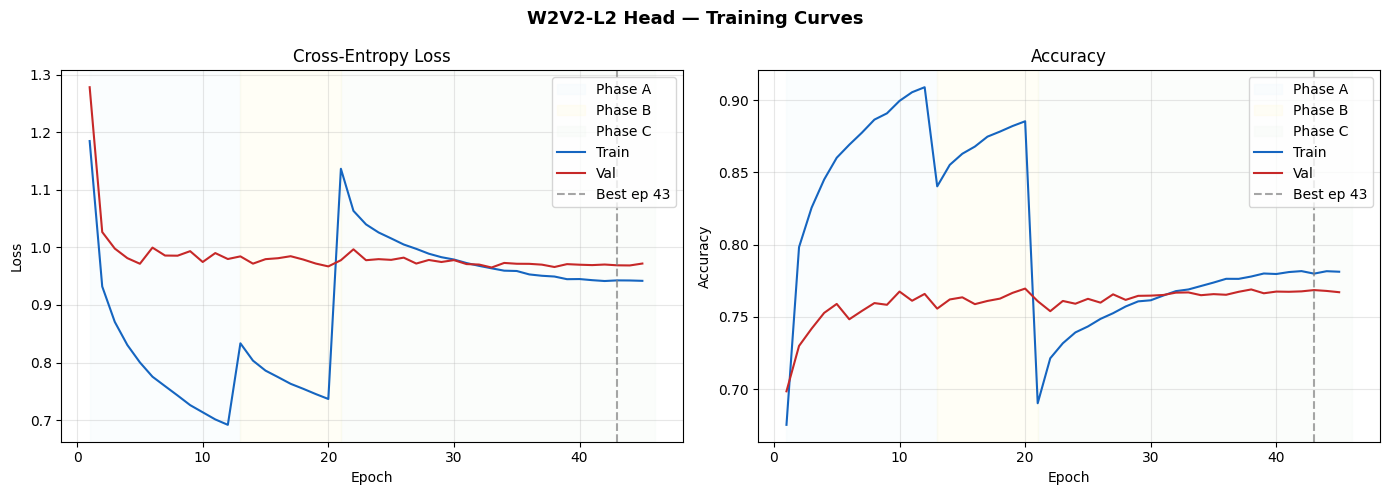

Saved -> training_curves.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = list(range(1, len(history['train_loss']) + 1))

# Shade phase regions
phase_colors = {'A': '#e3f2fd', 'B': '#fff9c4', 'C': '#e8f5e9'}
ph_starts = {}
for i, ph in enumerate(history['phase']):
    if ph not in ph_starts:
        ph_starts[ph] = i
ph_order = sorted(ph_starts, key=lambda p: ph_starts[p])
for idx, ph in enumerate(ph_order):
    start = ph_starts[ph] + 1
    end   = ph_starts[ph_order[idx + 1]] + 1 if idx + 1 < len(ph_order) else epochs_x[-1] + 1
    for ax in axes:
        ax.axvspan(start, end, alpha=0.15, color=phase_colors[ph], label=f'Phase {ph}')

axes[0].plot(epochs_x, history['train_loss'], label='Train', color='#1565C0', lw=1.5)
axes[0].plot(epochs_x, history['val_loss'],   label='Val',   color='#C62828', lw=1.5)
axes[0].axvline(best_epoch, color='gray', ls='--', alpha=0.7, label=f'Best ep {best_epoch}')
axes[0].set_title('Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_x, history['train_acc'], label='Train', color='#1565C0', lw=1.5)
axes[1].plot(epochs_x, history['val_acc'],   label='Val',   color='#C62828', lw=1.5)
axes[1].axvline(best_epoch, color='gray', ls='--', alpha=0.7, label=f'Best ep {best_epoch}')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('W2V2-L2 Head — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(output_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> training_curves.png')

## Cell 7 — Load best model and evaluate on test set

In [9]:
import pathlib
torch.serialization.add_safe_globals([pathlib.PosixPath, pathlib.Path])
ckpt = torch.load(output_dir / 'best_model.pt', map_location=device, weights_only=True)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded best model')
print(f'  epoch    : {ckpt["epoch"]}')
print(f'  phase    : {ckpt["phase"]}')
print(f'  val_loss : {ckpt["val_loss"]:.6f}')
print(f'  val_acc  : {ckpt["val_acc"]:.4f}')


def evaluate(loader):
    all_logits, all_y = [], []
    with torch.no_grad():
        for X, y in loader:
            all_logits.append(model(X.to(device)).cpu())
            all_y.append(y)
    logits = torch.cat(all_logits)
    y_true = torch.cat(all_y).numpy()
    probs  = torch.softmax(logits, dim=1).numpy()
    preds  = logits.argmax(1).numpy()
    return y_true, preds, probs


y_true, y_pred, y_prob = evaluate(test_loader)

test_acc      = accuracy_score(y_true, y_pred)
test_macro_f1 = f1_score(y_true, y_pred, average='macro')
macro_auc     = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')

print()
print('=== Test Results ===')
print(f'Accuracy  : {test_acc:.4f}')
print(f'Macro F1  : {test_macro_f1:.4f}')
print(f'Macro AUC : {macro_auc:.4f}')

Loaded best model
  epoch    : 43
  phase    : C
  val_loss : 0.968886
  val_acc  : 0.7685

=== Test Results ===
Accuracy  : 0.7806
Macro F1  : 0.7626
Macro AUC : 0.9605


## Cell 8 — Confusion matrix

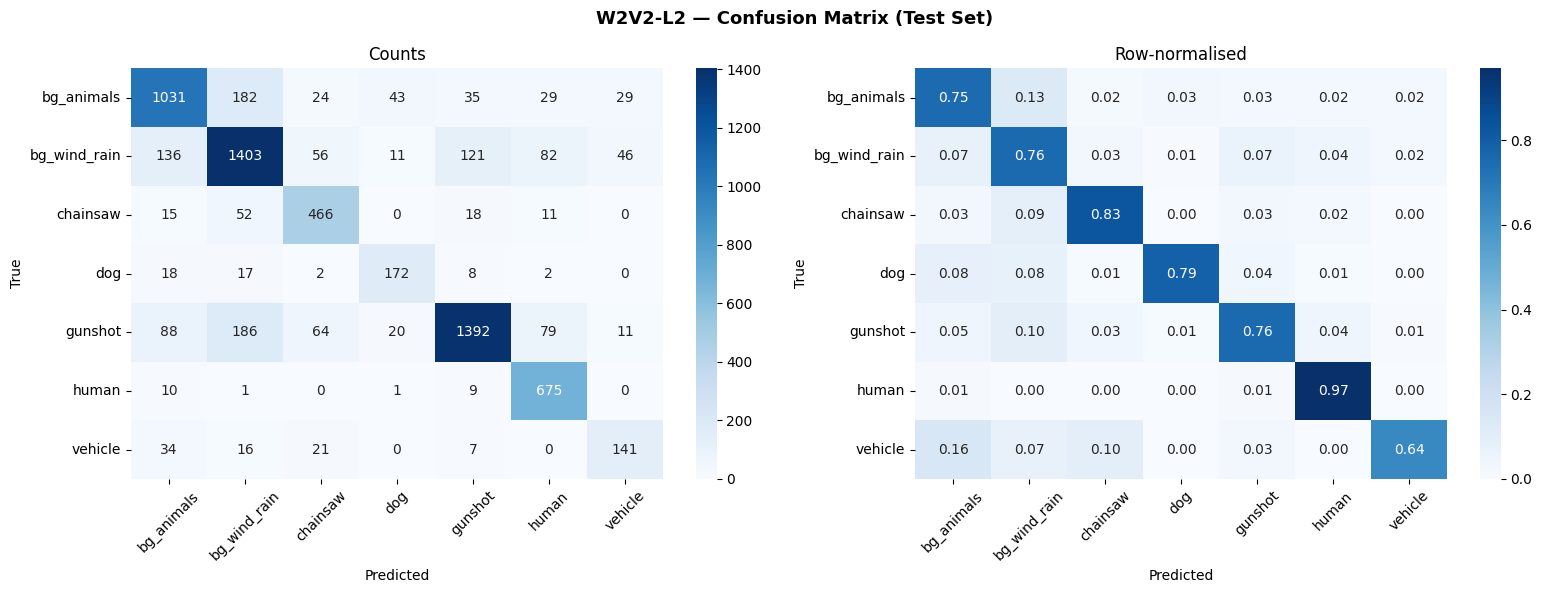

Saved -> confusion_matrix.png


In [10]:
class_names = CFG['class_names']
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Counts', 'Row-normalised']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=True)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('W2V2-L2 — Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(output_dir / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> confusion_matrix.png')

## Cell 9 — Per-class metrics

In [11]:
per_class_f1  = f1_score(y_true, y_pred, average=None)
per_class_auc = {}
for i, name in enumerate(class_names):
    binary_y = (y_true == i).astype(int)
    per_class_auc[name] = roc_auc_score(binary_y, y_prob[:, i])

print(f'{"Class":<22}  {"F1":>6}  {"AUC":>6}')
print('-' * 40)
for i, name in enumerate(class_names):
    print(f'{name:<22}  {per_class_f1[i]:>6.4f}  {per_class_auc[name]:>6.4f}')
print('-' * 40)
print(f'{"macro":<22}  {test_macro_f1:>6.4f}  {macro_auc:>6.4f}')

Class                       F1     AUC
----------------------------------------
bg_animals              0.7623  0.9504
bg_wind_rain            0.7559  0.9269
chainsaw                0.7799  0.9684
dog                     0.7382  0.9729
gunshot                 0.8117  0.9445
human                   0.8577  0.9933
vehicle                 0.6323  0.9673
----------------------------------------
macro                   0.7626  0.9605


## Cell 10 — Per-class ROC curves

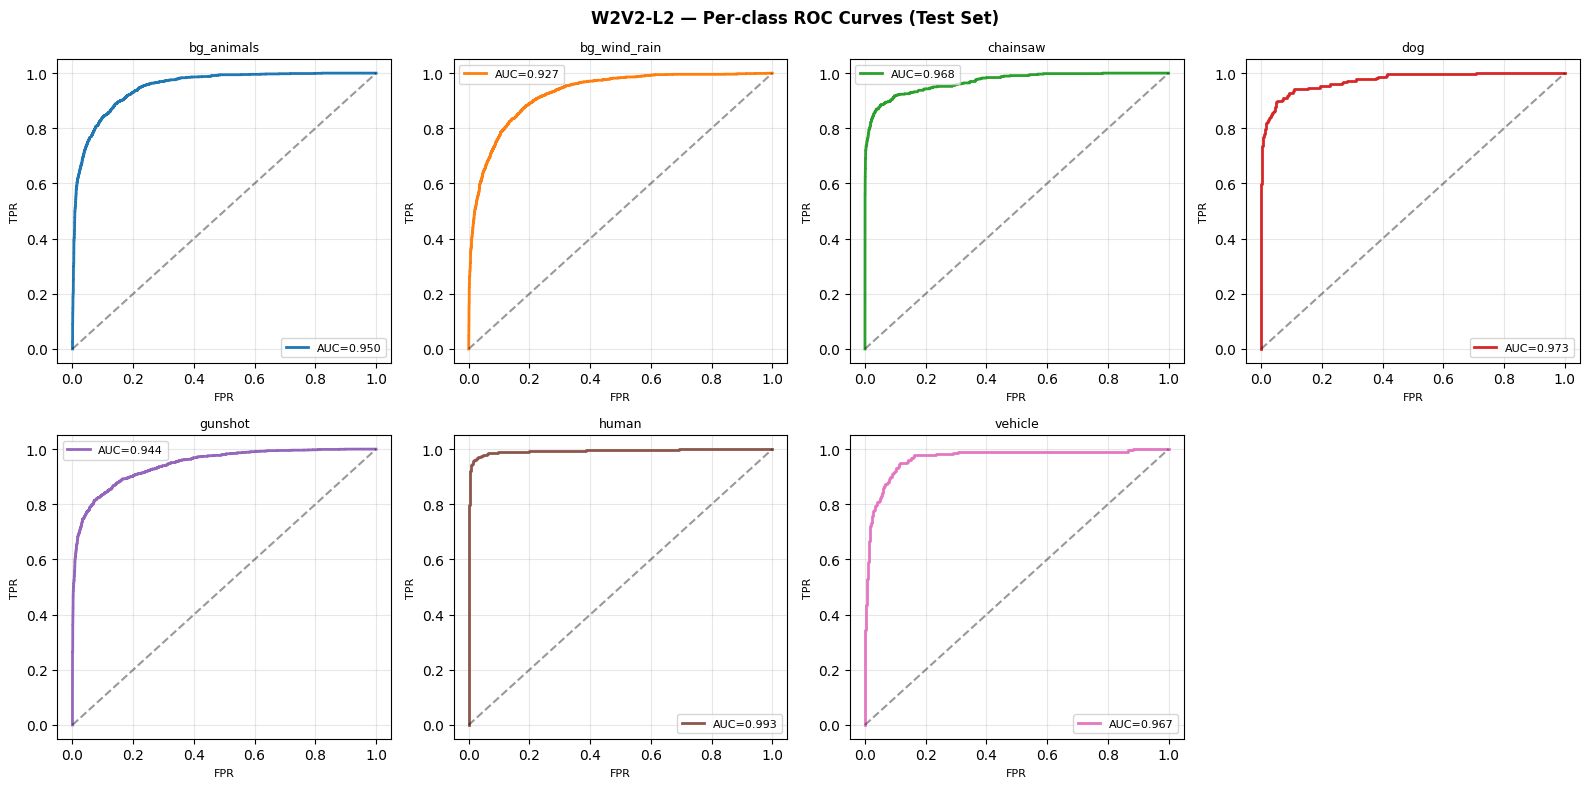

Saved -> roc_curves.png


In [12]:
n_cols = 4
n_rows = math.ceil(CFG['n_classes'] / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()
colors = plt.cm.tab10.colors

for i, name in enumerate(class_names):
    binary_y = (y_true == i).astype(int)
    fpr, tpr, _ = roc_curve(binary_y, y_prob[:, i])
    auc = per_class_auc[name]
    axes[i].plot(fpr, tpr, color=colors[i], lw=2, label=f'AUC={auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.4)
    axes[i].set_title(name, fontsize=9)
    axes[i].set_xlabel('FPR', fontsize=8)
    axes[i].set_ylabel('TPR', fontsize=8)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('W2V2-L2 — Per-class ROC Curves (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(output_dir / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> roc_curves.png')

## Cell 11 — ONNX export

In [13]:
onnx_path = output_dir / 'w2v2_head.onnx'
dummy = torch.randn(1, CFG['embed_dim'], device=device)

model.eval()
torch.onnx.export(
    model, dummy, onnx_path,
    input_names=['embedding'],
    output_names=['logits'],
    dynamic_axes={'embedding': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=17,
    dynamo=False,
)
size_kb = onnx_path.stat().st_size / 1024
print(f'ONNX exported -> {onnx_path}  ({size_kb:.1f} KB)')

/tmp/ipykernel_58/2217946503.py:5: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX exported -> /kaggle/working/w2v2_l2/w2v2_head.onnx  (2071.6 KB)


## Cell 12 — Save results

In [14]:
results = {
    'model':          'W2V2Head',
    'backbone':       'facebook/wav2vec2-base',
    'w2v2_layer':     2,
    'embed_dim':      CFG['embed_dim'],
    'hidden_dims':    CFG['hidden_dims'],
    'n_params_head':  n_params,
    'best_epoch':     best_epoch,
    'best_phase':     best_phase,
    'best_val_f1':    round(float(best_val_f1), 6),
    'test_acc':       round(float(test_acc),      6),
    'test_macro_f1':  round(float(test_macro_f1), 6),
    'macro_auc':      round(float(macro_auc),     6),
    'per_class_f1':   {name: round(float(f), 6) for name, f in zip(class_names, per_class_f1)},
    'per_class_auc':  {k: round(v, 6) for k, v in per_class_auc.items()},
    'best_config':    ckpt.get('exp'),
    'experiments':    json.loads((output_dir / 'experiments.json').read_text())
                      if (output_dir / 'experiments.json').exists() else None,
    'history': {
        'train_loss': history['train_loss'],
        'val_loss'  : history['val_loss'],
        'train_acc' : history['train_acc'],
        'val_acc'   : history['val_acc'],
        'val_f1'    : history['val_f1'],
        'lr'        : history['lr'],
        'phase'     : history['phase'],
    },
}

results_path = output_dir / 'results.json'
results_path.write_text(json.dumps(results, indent=2))
print(f'Results saved -> {results_path}')
print()
print(f'Model     : W2V2-L2 (frozen backbone + MLP head)')
print(f"Best cfg  : {ckpt.get('exp', {}).get('name', 'n/a')}")
print(f'Accuracy  : {test_acc:.4f}')
print(f'Macro F1  : {test_macro_f1:.4f}')
print(f'Macro AUC : {macro_auc:.4f}')

Results saved -> /kaggle/working/w2v2_l2/results.json

Model     : W2V2-L2 (frozen backbone + MLP head)
Best cfg  : A_baseline
Accuracy  : 0.7806
Macro F1  : 0.7626
Macro AUC : 0.9605


In [15]:
# ── Appendix — strict-linear head ablation ────────────────────────────────────
# The 3 experiments above tune the MLP head (768->512->256->7). The proposal
# abbreviates W2V2-L2 as a *linear* head (Geldenhuys & Niesler, 2026), so we also
# train a single Linear(768->7) through the SAME curriculum and report both.
# This is an architecture ablation — it does not change model selection above.
lin_exp = {'name': 'linear_head', 'lr': 3e-4, 'batch_size': 512, 'weight_decay': 1e-4,
           'dropout': 0.0, 'label_smooth': 0.10, 'hidden_dims': []}
lin_f1, lin_ep, lin_ph, lin_hist, lin_ckpt = run_experiment(lin_exp)

lin_model = W2V2Head(CFG['embed_dim'], [], CFG['n_classes'], 0.0).to(device)
lin_model.load_state_dict(torch.load(lin_ckpt, map_location=device)['model_state'])
lin_model.eval()
lin_params = sum(p.numel() for p in lin_model.parameters())


def _eval_test(mdl):
    ys, ps = [], []
    with torch.no_grad():
        for X, y in test_loader:
            ps.append(mdl(X.to(device)).argmax(1).cpu()); ys.append(y)
    yt, pr = torch.cat(ys).numpy(), torch.cat(ps).numpy()
    return accuracy_score(yt, pr), f1_score(yt, pr, average='macro')


lin_acc, lin_test_f1 = _eval_test(lin_model)

print("\n" + "=" * 60)
print("W2V2-L2 head architecture ablation")
print(f"  {'head':<18}{'params':>8}  {'val_F1':>7}  {'test_acc':>9}  {'test_F1':>8}")
print(f"  {'MLP 768-512-256':<18}{n_params:>8,}  {best_val_f1:>7.4f}  {test_acc:>9.4f}  {test_macro_f1:>8.4f}")
print(f"  {'linear 768->7':<18}{lin_params:>8,}  {lin_f1:>7.4f}  {lin_acc:>9.4f}  {lin_test_f1:>8.4f}")
print("=" * 60)

(output_dir / 'linear_head_ablation.json').write_text(json.dumps({
    'mlp_head': {
        'params': n_params, 'val_f1': round(float(best_val_f1), 6),
        'test_acc': round(float(test_acc), 6), 'test_macro_f1': round(float(test_macro_f1), 6),
    },
    'linear_head': {
        'params': lin_params, 'val_f1': round(float(lin_f1), 6),
        'best_epoch': lin_ep, 'best_phase': lin_ph,
        'test_acc': round(float(lin_acc), 6), 'test_macro_f1': round(float(lin_test_f1), 6),
        'history': lin_hist,
    },
}, indent=2))
print("Saved -> linear_head_ablation.json")


=== linear_head === lr=3e-04 bs=512 wd=1e-04 drop=0.0 ls=0.1 hidden=[]
  ph epoch         lr   tr_loss  tr_acc   va_loss  va_acc   va_f1
   A     1   3.00e-04    1.8741  0.3995    1.8105  0.3987  0.2352  * best
   A     2   3.00e-04    1.7654  0.4535    1.7273  0.4269  0.2651  * best
   A     3   2.98e-04    1.6893  0.4871    1.6717  0.4443  0.2801  * best
   A     4   2.97e-04    1.6314  0.5114    1.6310  0.4558  0.2899  * best
   A     5   2.94e-04    1.5846  0.5317    1.5986  0.4633  0.2945  * best
   A     6   2.91e-04    1.5452  0.5467    1.5714  0.4703  0.2990  * best
   A     7   2.86e-04    1.5114  0.5562    1.5482  0.4754  0.3037  * best
   A     8   2.82e-04    1.4817  0.5643    1.5276  0.4844  0.3154  * best
   A     9   2.76e-04    1.4556  0.5737    1.5095  0.4906  0.3223  * best
   A    10   2.70e-04    1.4324  0.5784    1.4928  0.4958  0.3301  * best
   A    11   2.63e-04    1.4118  0.5845    1.4773  0.5029  0.3410  * best
   A    12   2.56e-04    1.3932  0.5901    1.464